# Week 3 Assignment (Fixed Version)

Analyzing pedestrian counts and weather data in NYC.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
url = "https://data.cityofnewyork.us/api/views/6fi9-q3ta/rows.csv?accessType=DOWNLOAD"
df = pd.read_csv(url)
df['hour_beginning'] = pd.to_datetime(df['hour_beginning'])
df.head()

<ipython-input-1-6b4df250d1a7>:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['hour_beginning'] = pd.to_datetime(df['hour_beginning'])


,hour_beginning,location,Pedestrians,Towards Manhattan,Towards Brooklyn,weather_summary,temperature,precipitation,lat,long,events,Location1
0,2019-04-30 00:00:00,Brooklyn Bridge,3,3,0,NaN,NaN,NaN,40.708164,-73.999509,NaN,"(40.7081639691088, -73.9995087014816)"
1,2019-12-31 22:00:00,Brooklyn Bridge,10,9,1,cloudy,42.0,0.0005,40.708164,-73.999509,NaN,"(40.7081639691088, -73.9995087014816)"
2,2019-12-31 23:00:00,Brooklyn Bridge,2,0,2,cloudy,42.0,0.0004,40.708164,-73.999509,NaN,"(40.7081639691088, -73.9995087014816)"
3,2019-12-31 21:00:00,Brooklyn Bridge,12,0,12,cloudy,42.0,0.0036,40.708164,-73.999509,NaN,"(40.7081639691088, -73.9995087014816)"
4,2019-04-01 03:00:00,Brooklyn Bridge,1,0,1,clear-night,36.0,0.0000,40.708164,-73.999509,NaN,"(40.7081639691088, -73.9995087014816)"


## Question 1: Weekday Line Plot for Pedestrian Counts

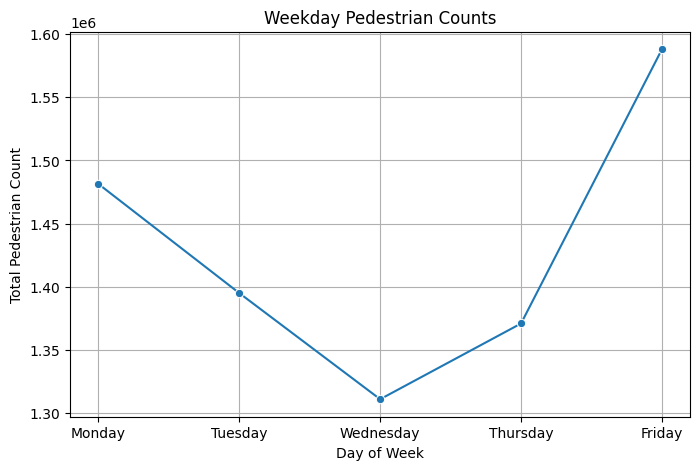

In [2]:
df['DayOfWeek'] = df['hour_beginning'].dt.day_name()
weekday_df = df[df['DayOfWeek'].isin(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'])]

weekday_counts = weekday_df.groupby('DayOfWeek')['Pedestrians'].sum().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'])

plt.figure(figsize=(8, 5))
sns.lineplot(data=weekday_counts, marker='o')
plt.title("Weekday Pedestrian Counts")
plt.xlabel("Day of Week")
plt.ylabel("Total Pedestrian Count")
plt.grid(True)
plt.show()

## Question 2: Brooklyn Bridge 2019 - Weather Impact

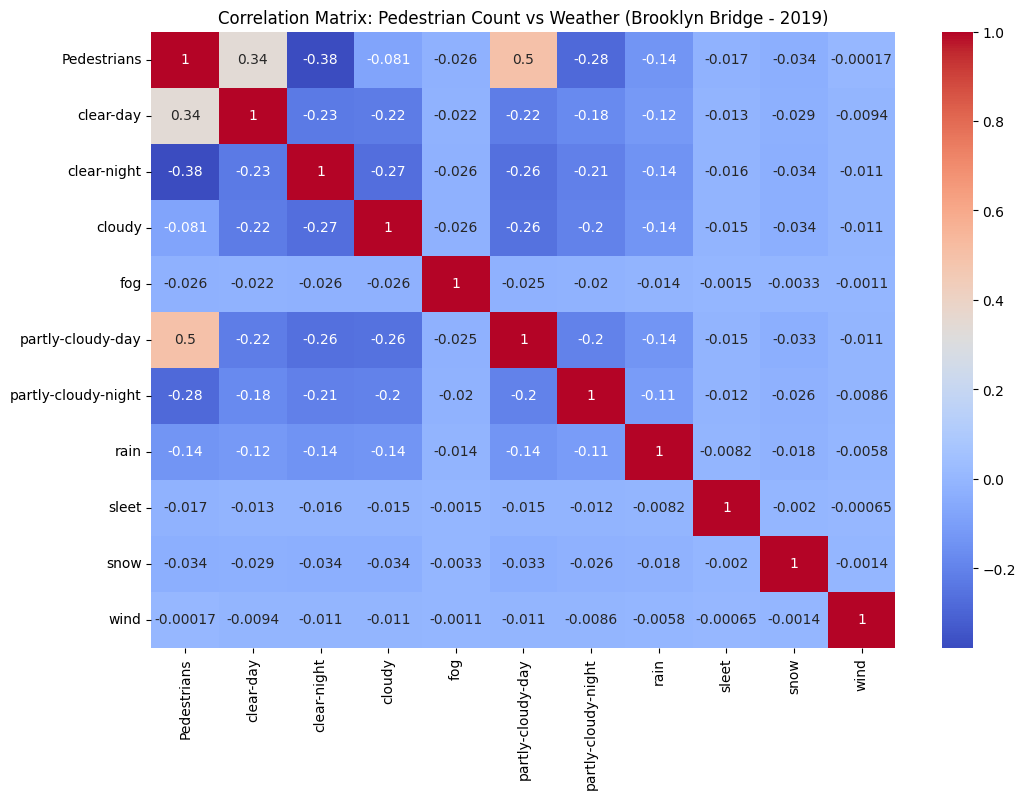

In [3]:
df['year'] = df['hour_beginning'].dt.year
brooklyn_2019 = df[(df['location'] == 'Brooklyn Bridge') & (df['year'] == 2019)]

# One-hot encode weather
weather_encoded = pd.get_dummies(brooklyn_2019['weather_summary'])
weather_data = pd.concat([brooklyn_2019[['Pedestrians']], weather_encoded], axis=1)

# Correlation matrix
cor_matrix = weather_data.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(cor_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix: Pedestrian Count vs Weather (Brooklyn Bridge - 2019)")
plt.show()

## Question 3: Time of Day Categorization and Pedestrian Analysis

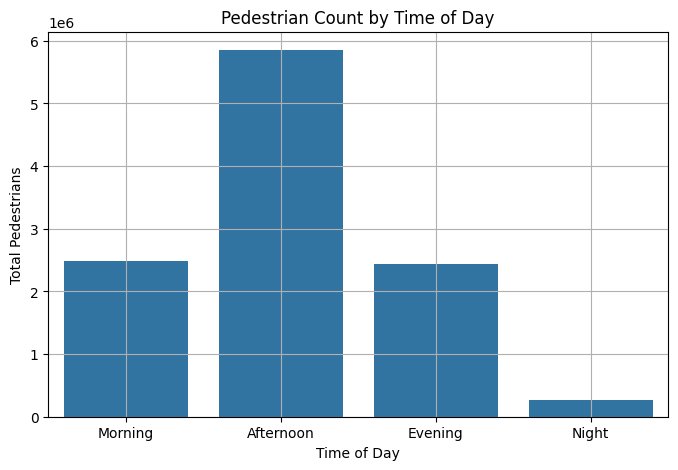

In [4]:
def categorize_time(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['hour'] = df['hour_beginning'].dt.hour
df['TimeOfDay'] = df['hour'].apply(categorize_time)

time_counts = df.groupby('TimeOfDay')['Pedestrians'].sum().reindex(['Morning', 'Afternoon', 'Evening', 'Night'])

plt.figure(figsize=(8, 5))
sns.barplot(x=time_counts.index, y=time_counts.values)
plt.title("Pedestrian Count by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Total Pedestrians")
plt.grid(True)
plt.show()